In [98]:
import os
from dotenv import load_dotenv
load_dotenv()

try:
    os.environ['GROQ_API_KEY']=os.getenv('GROQ_API_KEY')
    print("GROQ API KEY LOADED")
except:
    print("No GROQ API KEY found in the .env file")

GROQ API KEY LOADED


In [99]:
from langchain_groq import ChatGroq
llm=ChatGroq(model='openai/gpt-oss-20b')
result=llm.invoke("hey, how are you?")
print(result.content)

Hey! I’m doing great—thanks for asking. How about you? Anything interesting going on?


In [100]:
from langgraph.graph import START, END, StateGraph
from typing_extensions import TypedDict
from pydantic import BaseModel
from IPython.display import display, Image

from langchain_core.messages import HumanMessage, SystemMessage

In [101]:
class Creator(TypedDict):
    topic:str
    joke:str
    poem:str
    story:str
    agg:str

In [102]:
def joke(state:Creator):
    """First llm to Genrate the joke """
    print("Joke:-----------")
    message=llm.invoke(f"Give me a joke on {state["topic"]} ")
    print("******"*50)
    return {"joke":message.content}


def poem(state:Creator):
    """Second llm to improve the poem """
    print("Poem:-----------")
    message=llm.invoke(f"igive me the poem {state["topic"]}")
    print("******"*50)
    return {"poem":message.content}



def story(state:Creator):
    """third llm to generate the Story """
    print("Story:-----------")
    message=llm.invoke(f"give me the story on  {state["topic"]}")
    print("******"*50)
    return {"story":message.content}


def punchline(state:Creator):
    if "joke" in state["topic"]:
        return "joke"
    elif "story" in state["topic"]:
        return "story"
    elif "poem" in state["topic"]:
        return "poem"
    else:
        return "Fail"
    
def agg(state:Creator):
    """Combine the joke and story into a single output"""
    
    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"agg":combined}



# routing the tOpic to all the nodes

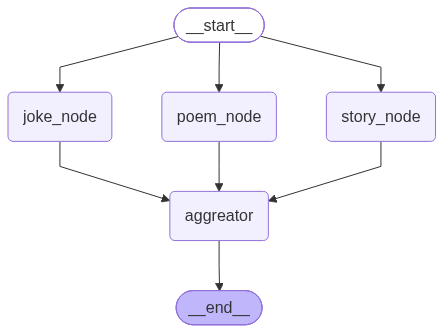

In [103]:
graph=StateGraph(Creator)
graph.add_node("joke_node",joke)
graph.add_node("story_node",story)
graph.add_node("poem_node",poem)
graph.add_node("aggreator",agg)

graph.add_edge(START,"joke_node")
graph.add_edge(START,"story_node")
graph.add_edge(START,"poem_node")
graph.add_edge("joke_node","aggreator")
graph.add_edge("poem_node","aggreator")
graph.add_edge("story_node","aggreator")
graph.add_edge("aggreator",END)

react=graph.compile()
display(Image(react.get_graph().draw_mermaid_png()))

In [104]:
state=react.invoke({"topic":"cat"})

Joke:-----------
Poem:-----------
Story:-----------
************************************************************************************************************************************************************************************************************************************************************************************************************
************************************************************************************************************************************************************************************************************************************************************************************************************
************************************************************************************************************************************************************************************************************************************************************************************************************


In [105]:
print(state['agg'])

Here's a story, joke, and poem about cat!

STORY:
**The Midnight Map**

In the quiet town of Willowbrook, where the streets were lined with old elm trees and the air smelled faintly of rain and baking bread, lived a cat named Whiskers. Whiskers was not an ordinary housecat; she had a coat as silvery as moonlight and a pair of green eyes that seemed to hold the secrets of the night.

Every evening, after the town’s lamps flickered on and the last of the day’s chores were finished, Whiskers would slip out of the front door, her paws silent on the cobblestones. She had a particular habit: she always walked straight to the old stone well at the edge of the park, a place the townsfolk whispered about but rarely visited.

One night, as the moon hung high and silver, Whiskers approached the well. The stone was cool against her paws, and the water below reflected the stars like a mirror. She peered down, her whiskers twitching. Suddenly, a faint glow pulsed from the bottom of the well, as if s

## Routing the topic to specifc node only


In [106]:
from pydantic import Field
from typing_extensions import Literal

In [107]:
class Creator(TypedDict):
    input:str
    decision:str
    output:str

In [ ]:
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(None, description="The next step in the routing process")

router = llm.with_structured_output(Route)



In [109]:
def joke(state:Creator):
    """First llm to Genrate the joke """
    print("Joke:-----------")
    message=llm.invoke(f"Give me a joke on {state["input"]} ")
    print("******"*50)
    return {"output":message.content}


def poem(state:Creator):
    """Second llm to improve the poem """
    print("Poem:-----------")
    message=llm.invoke(f"igive me the poem {state["input"]}")
    print("******"*50)
    return {"output":message.content}



def story(state:Creator):
    """third llm to generate the Story """
    print("Story:-----------")
    message=llm.invoke(f"give me the story on  {state["input"]}")
    print("******"*50)
    return {"output":message.content}


def rout(state:Creator):
    if state["decision"]=="joke":
        return "joke"
    elif state["decision"]=="poem":
        return "poem"
    else:
        return "story"
    

def llm_call_router(state: Creator):
    """Route the input to the appropriate node"""

    # Run the augmented LLM with structured output to serve as routing logic
    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke, or poem based on the user's request."
            ),
            HumanMessage(content=state["input"]),
        ]
    )

    return {"decision": decision.step}


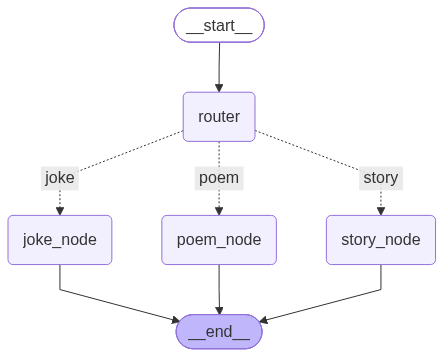

In [110]:
graph=StateGraph(Creator)


graph.add_node("router",llm_call_router)
graph.add_node("story_node",story)
graph.add_node("poem_node",poem)
graph.add_node("joke_node",joke)

graph.add_edge(START,"router")
graph.add_conditional_edges("router",rout,{"joke":"joke_node","poem":"poem_node","story":"story_node"})

graph.add_edge("joke_node",END)
graph.add_edge("poem_node",END)
graph.add_edge("story_node",END)

react=graph.compile()
display(Image(react.get_graph().draw_mermaid_png()))

In [111]:
result=react.invoke({"input":"give me a poem on cat"})

Poem:-----------
************************************************************************************************************************************************************************************************************************************************************************************************************


In [112]:
print(result['output'])

**Whisper of the Velvet Paw**

In moonlit alleys, where the night is thin,  
A silver silhouette slips through the din.  
Soft paws on cobblestones, a silent hymn—  
A living shadow, a whiskered dream.

Eyes like lanterns, amber and bright,  
Glimmering pools that hold the night.  
They flicker, they glow, they gleam with delight,  
Chasing the echo of a distant kite.

Fur as velvet, a midnight cloak,  
Each strand a story, each curl a joke.  
Graceful as a feather, quick as a spoke,  
The world is a canvas for the cat to poke.

They leap from rooftops, a daring dance,  
With a heart that beats in a wild trance.  
A hunter, a lover, a fleeting romance,  
In every purr, a quiet romance.

When dawn spills gold across the street,  
The cat curls in a sunlit seat.  
Dreaming of stars and midnight heat,  
In the hush of dawn, the world feels complete.
